# Treinamento KNN

Notebook alinhado ao fluxo do `SVM_training.py`: segmenta??o do regime permanente, janelamento de 50 amostras, extra??o de m?dia, desvio padr?o, assimetria, curtose e RMS, divis?o estratificada 60/40 e sele??o de hiperpar?metros por `GridSearchCV` com `cv=3`.

In [20]:
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [21]:
# Ajuste este caminho somente se o notebook for executado fora da pasta do projeto.
THIS_FOLDER = Path.cwd()

if not (THIS_FOLDER / "dados").exists() and (THIS_FOLDER / "knn" / "dados").exists():
    THIS_FOLDER = THIS_FOLDER / "knn"

DATA_FOLDER = THIS_FOLDER / "dados"

FOLDERS = {
    "normal": DATA_FOLDER / "normal",
    "desbalanceada": DATA_FOLDER / "helice_desbalanceada",
    "quebrada": DATA_FOLDER / "helice_quebrada",
    "invertida": DATA_FOLDER / "rotacao_invertida",
}

DROP_COLUMNS = ["Celula3_Kgf", "Tempo", "RPM", "Potencia_W"]
MODEL_PATH = THIS_FOLDER / "KNN_bestModel.pkl"
CONFUSION_MATRIX_PATH = THIS_FOLDER / "KNN_confusion_matrix.png"
ARTICLE_CONFUSION_MATRIX_PATH = THIS_FOLDER / "artigo" / "imgs" / "knn_confusion_matrix.png"
FEATURES_PATH = THIS_FOLDER / "KNN_features.csv"
FEATURE_NAMES_PATH = THIS_FOLDER / "KNN_feature_names.txt"
METRICS_TXT_PATH = THIS_FOLDER / "KNN_metrics.txt"
METRICS_CSV_PATH = THIS_FOLDER / "KNN_metrics.csv"

print(f"Pasta base: {THIS_FOLDER}")
print(f"Pasta de dados: {DATA_FOLDER}")

Pasta base: c:\Users\vinic\OneDrive\Ambiente de Trabalho\Faculdade\machine learning\knn
Pasta de dados: c:\Users\vinic\OneDrive\Ambiente de Trabalho\Faculdade\machine learning\knn\dados


In [22]:
def transitory_stacionary(df):
    loc_i = df.columns.get_loc("Corrente_A") + 1

    q1 = df["Corrente_A"].quantile(0.30)
    q3 = df["Corrente_A"].quantile(0.70)
    df_40 = df[(df["Corrente_A"] >= q1) & (df["Corrente_A"] <= q3)]

    flag_stac = False
    flag_transitory_1 = True
    transitory_1 = 0
    transitory_2 = None
    mean = df_40["Corrente_A"].mean()

    for idx, row in enumerate(df.itertuples()):
        corrente = abs(row[loc_i])

        if 0.99 * mean <= corrente <= 1.3 * mean and flag_transitory_1:
            transitory_1 = idx + 12
            flag_stac = True
            flag_transitory_1 = False

        if flag_stac and 0.3 * mean <= corrente <= 0.82 * mean:
            transitory_2 = idx - 8
            break

    df_0 = df.iloc[:transitory_1]

    if transitory_2 is not None:
        df_1 = df.iloc[transitory_1:transitory_2]
        df_2 = df.iloc[transitory_2:]
    else:
        df_1 = df.iloc[transitory_1:]
        df_2 = None

    return df_0, df_1, df_2

In [23]:
def window_statistics(df, condicao):
    row = {"condicao": condicao}

    for coluna in df.columns:
        valores = df[coluna].dropna()

        if valores.empty:
            continue

        row[f"{coluna}_mean"] = valores.mean()
        row[f"{coluna}_std"] = valores.std()
        row[f"{coluna}_skew"] = valores.skew()
        row[f"{coluna}_kurtosis"] = valores.kurtosis()
        row[f"{coluna}_rms"] = np.sqrt(np.mean(valores**2))

    return row


def extract_features(window_length=50, min_window_length=10):
    dados_extraidos = []

    for condicao, folder in FOLDERS.items():
        files = [folder / name for name in os.listdir(folder) if name.endswith(".xlsx")]

        print(f"\n================== {condicao} ==================")
        print(f"Arquivos encontrados: {len(files)}")

        for file_path in files:
            df = pd.read_excel(file_path)
            df = df.drop(columns=DROP_COLUMNS, errors="ignore")

            _, df_regime, _ = transitory_stacionary(df)
            df_regime = df_regime.dropna()

            if df_regime.empty:
                print(f"Aviso: regime permanente vazio em {file_path.name}")
                continue

            for inicio in range(0, len(df_regime), window_length):
                janela = df_regime.iloc[inicio : inicio + window_length]

                if len(janela) >= min_window_length:
                    dados_extraidos.append(window_statistics(janela, condicao=condicao))

    return pd.DataFrame(dados_extraidos)

In [24]:
def save_training_artifacts(df_features, feature_names, metrics, classification_text, best_params):
    df_features.to_csv(FEATURES_PATH, index=False)

    with open(FEATURE_NAMES_PATH, "w", encoding="utf-8") as file:
        for name in feature_names:
            file.write(f"{name}\n")

    pd.DataFrame([metrics]).to_csv(METRICS_CSV_PATH, index=False)

    with open(METRICS_TXT_PATH, "w", encoding="utf-8") as file:
        file.write("=== Melhor KNN ===\n")
        for key, value in best_params.items():
            file.write(f"{key}: {value}\n")

        file.write("\n=== Metricas principais ===\n")
        for key, value in metrics.items():
            if isinstance(value, float):
                file.write(f"{key}: {value:.4f}\n")
            else:
                file.write(f"{key}: {value}\n")

        file.write("\n=== Relatorio de classificacao ===\n")
        file.write(classification_text)

    print(f"Features salvas em: {FEATURES_PATH}")
    print(f"Nomes das features salvos em: {FEATURE_NAMES_PATH}")
    print(f"M?tricas salvas em: {METRICS_TXT_PATH}")
    print(f"M?tricas em CSV salvas em: {METRICS_CSV_PATH}")

In [25]:
def train_knn(df_features):
    X = df_features.drop(columns=["condicao"])
    y = df_features["condicao"]

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.4,
        random_state=42,
        stratify=y,
    )

    pipeline = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier()),
        ]
    )

    param_grid = {
        "knn__n_neighbors": [1, 3, 5, 7],
        "knn__weights": ["uniform", "distance"],
        "knn__metric": ["euclidean", "manhattan"],
    }

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=3,
        scoring="accuracy",
        n_jobs=-1,
    )

    grid_search.fit(X_train, y_train)

    print("\n=== Dataset extra?do ===")
    print(f"Total de janelas: {len(df_features)}")
    print("Janelas por classe:")
    print(y.value_counts())

    print("\n=== Melhor KNN ===")
    print("Melhores hiperpar?metros:", grid_search.best_params_)
    print("Melhor acur?cia m?dia:", grid_search.best_score_)

    y_pred = grid_search.predict(X_test)
    y_proba = grid_search.predict_proba(X_test)

    print("\n=== Relat?rio no conjunto de teste ===")
    report = classification_report(y_test, y_pred, zero_division=0)
    print(report)

    labels = grid_search.best_estimator_.classes_

    accuracy = accuracy_score(y_test, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    roc_auc_macro = roc_auc_score(
        y_test,
        y_proba,
        labels=labels,
        multi_class="ovr",
        average="macro",
    )

    print("\n=== M?tricas principais ===")
    print(f"Acur?cia: {accuracy:.4f}")
    print(f"Balanced accuracy: {balanced_accuracy:.4f}")
    print(f"Precis?o macro: {precision_macro:.4f}")
    print(f"Recall macro: {recall_macro:.4f}")
    print(f"F1-score macro: {f1_macro:.4f}")
    print(f"ROC-AUC macro OvR: {roc_auc_macro:.4f}")

    cm = confusion_matrix(y_test, y_pred, labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.title("Matriz de Confus?o - KNN")
    plt.ylabel("Condi??o real")
    plt.xlabel("Condi??o prevista")
    plt.tight_layout()
    plt.savefig(CONFUSION_MATRIX_PATH, dpi=300)
    if ARTICLE_CONFUSION_MATRIX_PATH.parent.exists():
        plt.savefig(ARTICLE_CONFUSION_MATRIX_PATH, dpi=300)
    plt.show()

    metrics = {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "roc_auc_macro_ovr": roc_auc_macro,
        "best_cv_accuracy": grid_search.best_score_,
        "total_windows": len(df_features),
        "train_windows": len(X_train),
        "test_windows": len(X_test),
    }

    save_training_artifacts(
        df_features=df_features,
        feature_names=X_train.columns,
        metrics=metrics,
        classification_text=report,
        best_params=grid_search.best_params_,
    )

    return grid_search.best_estimator_


================== normal ==================
Arquivos encontrados: 4



================== desbalanceada ==================
Arquivos encontrados: 4

================== quebrada ==================
Arquivos encontrados: 5

================== invertida ==================
Arquivos encontrados: 3

=== Dataset extra?do ===
Total de janelas: 130
Janelas por classe:
condicao
quebrada         38
normal           34
desbalanceada    33
invertida        25
Name: count, dtype: int64

=== Melhor KNN ===
Melhores hiperpar?metros: {'knn__metric': 'manhattan', 'knn__n_neighbors': 1, 'knn__weights': 'uniform'}
Melhor acur?cia m?dia: 0.8846153846153846

=== Relat?rio no conjunto de teste ===
               precision    recall  f1-score   support

desbalanceada       1.00      0.92      0.96        13
    invertida       1.00      1.00      1.00        10
       normal       0.75      0.64      0.69        14
     quebrada       0.72      0.87      0.79        15

     accuracy                           0.85        52
    macro avg       0.87      0.86      0.86        52
 

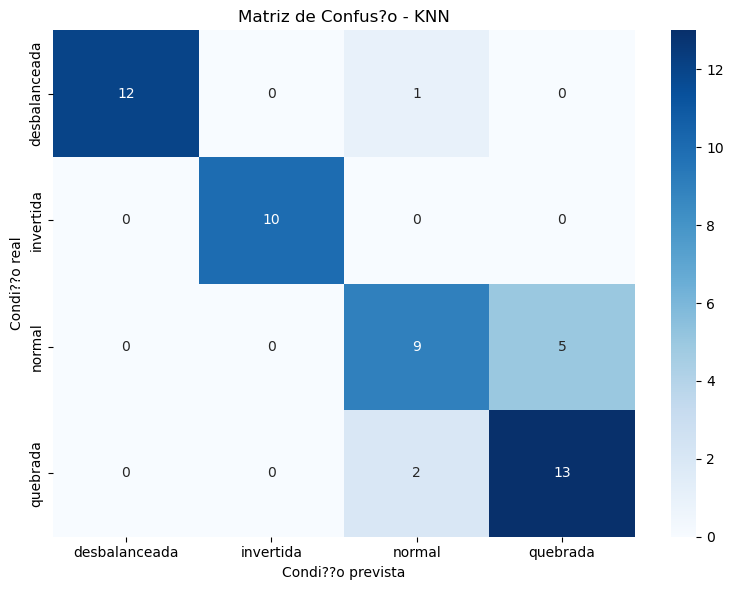

Features salvas em: c:\Users\vinic\OneDrive\Ambiente de Trabalho\Faculdade\machine learning\knn\KNN_features.csv
Nomes das features salvos em: c:\Users\vinic\OneDrive\Ambiente de Trabalho\Faculdade\machine learning\knn\KNN_feature_names.txt
M?tricas salvas em: c:\Users\vinic\OneDrive\Ambiente de Trabalho\Faculdade\machine learning\knn\KNN_metrics.txt
M?tricas em CSV salvas em: c:\Users\vinic\OneDrive\Ambiente de Trabalho\Faculdade\machine learning\knn\KNN_metrics.csv

Modelo salvo em: c:\Users\vinic\OneDrive\Ambiente de Trabalho\Faculdade\machine learning\knn\KNN_bestModel.pkl


In [26]:
features = extract_features(window_length=50)
best_model = train_knn(features)
joblib.dump(best_model, MODEL_PATH)
print(f"\nModelo salvo em: {MODEL_PATH}")